In [55]:
import os, sys
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from fastparquet import write

cwd = os.getcwd()
root_path = cwd
while '.venv' not in os.listdir(root_path):
    root_path =  os.path.dirname(root_path)
results_path = os.path.join(root_path,'results')
forecast_path = os.path.join(results_path,'forecast')
display(forecast_path)

'C:\\Users\\Utilisateur\\Desktop\\doctorat\\2. Recherche\\Article 1\\3. Python\\PhD_article_1\\results\\forecast'

In [56]:
ls_true = [f for f in os.listdir(forecast_path) if 'True' in f]
ls_pred = [f for f in os.listdir(forecast_path) if 'True' not in f]
display(ls_true, ls_pred)

['FR0000073272_True.parquet.gzip']

['FR0000073272_OHLCV_CNN.parquet.gzip',
 'FR0000073272_OHLCV_CNN_LSTM.parquet.gzip',
 'FR0000073272_OHLCV_LSTM.parquet.gzip']

In [57]:
data_name = ['OHLCV', 'FOB']
model_name = ['CNN', 'LSTM']

for file_true in ls_true:
    data_true = pd.read_parquet(os.path.join(forecast_path, file_true))
    
    res = pd.DataFrame()
    res2 = pd.DataFrame()
    
    for file_pred in ls_pred:
        data_pred = pd.read_parquet(os.path.join(forecast_path, file_pred))
        
        isin = file_pred.split('_')[0]
        data_mod = '_'.join(file_pred.split('.')[0].split('_')[1:])
        data = '_'.join([i for i in data_mod.split('_') if i in data_name])
        model = '_'.join([i for i in data_mod.split('_') if i in model_name])
        display(isin, data, model)
        
        mse = data_true.apply(lambda row: mean_squared_error(row, data_pred.loc[row.name]), axis=1)
        tmp = pd.DataFrame(mse, columns=['mse'])
        tmp[['isin','data', 'model']] = isin, data, model
        tmp['id_forecast'] = tmp.index
        
        sign_match = np.sign(data_true) == np.sign(data_pred)
        accuracy_row = sign_match.mean(axis=1)
        
        mae = data_true.apply(lambda row: mean_absolute_error(row, data_pred.loc[row.name]), axis=1)
        
        tmp['accuracy'] = accuracy_row
        tmp['mae'] = mae
        
        res = pd.concat([res, tmp], ignore_index=True)
        if "metrics_row.parquet.gzip" in os.listdir(cwd):
            write(os.path.join(cwd, "metrics_row.parquet.gzip"), tmp, compression='GZIP', append=True)
        else:
            write(os.path.join(cwd, "metrics_row.parquet.gzip"), tmp, compression='GZIP', append=False)
        
        mse = data_true.apply(lambda col: mean_squared_error(col, data_pred[col.name]), axis=0)
        tmp = pd.DataFrame(mse, columns=['mse'])
        tmp[['isin','data', 'model']] = isin, data, model
        tmp['target'] = tmp.index
        tmp['target'] = tmp['target'].apply(lambda row: int(row.split('_')[1]))
        
        sign_match = np.sign(data_true) == np.sign(data_pred)
        accuracy_row = sign_match.mean(axis=0)
        
        mae = data_true.apply(lambda col: mean_absolute_error(col, data_pred[col.name]), axis=0)
        
        tmp['accuracy'] = accuracy_row
        tmp['mae'] = mae
        
        res2 = pd.concat([res2, tmp], ignore_index=True).sort_values(['target'])
        if "metrics_col.parquet.gzip" in os.listdir(cwd):
            write(os.path.join(cwd, "metrics_col.parquet.gzip"), tmp, compression='GZIP', append=True)
        else:
            write(os.path.join(cwd, "metrics_col.parquet.gzip"), tmp, compression='GZIP', append=False)

'FR0000073272'

'OHLCV'

'CNN'

'FR0000073272'

'OHLCV'

'CNN_LSTM'

'FR0000073272'

'OHLCV'

'LSTM'

KeyError: 'data_mod'

In [70]:
df = pd.read_parquet("metrics_col.parquet.gzip")
for m in ['mse','mae','accuracy']:
    desc = df.groupby(['data','model'])[m].describe()
    pivot = desc.copy()
    pivot['skew'] = df.groupby(['data','model'])[m].skew()
    pivot['kurt'] = df.groupby(['data','model'])[m].apply(pd.DataFrame.kurt)
    pivot = pivot[['mean', '50%', 'skew', 'kurt']]
    pivot.columns = ['M', 'Mdn', 'Skew', 'Kurt']
    pivot = pivot.unstack(0).swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)#.round(2)
    display(pivot)

data         OHLCV                              
                 M       Mdn      Skew      Kurt
model                                           
CNN       0.000043  0.000047 -1.752404  3.368941
CNN_LSTM  0.000048  0.000048 -0.934341  1.214150
LSTM      0.000052  0.000052 -1.240388  1.835236

data         OHLCV                              
                 M       Mdn      Skew      Kurt
model                                           
CNN       0.005117  0.005370 -2.682318  7.871426
CNN_LSTM  0.005393  0.005462 -1.955698  5.505707
LSTM      0.005564  0.005869 -2.445986  6.810715

data         OHLCV                               
                 M       Mdn      Skew       Kurt
model                                            
CNN       0.505176  0.502513 -4.137329  32.055947
CNN_LSTM  0.513141  0.516332 -7.051460  62.778114
LSTM      0.471784  0.477387 -6.379455  54.302317

,FR0000073272_OHLCV_CNN,FR0000073272_OHLCV_CNN_LSTM,FR0000073272_OHLCV_LSTM
0,0.000073,0.000076,0.000059
1,0.000073,0.000075,0.000060
2,0.000088,0.000095,0.000068
3,0.000086,0.000090,0.000067
4,0.000069,0.000065,0.000060
...,...,...,...
393,0.000005,0.000008,0.000011
394,0.000005,0.000015,0.000005
395,0.000005,0.000008,0.000013
396,0.000006,0.000019,0.000004


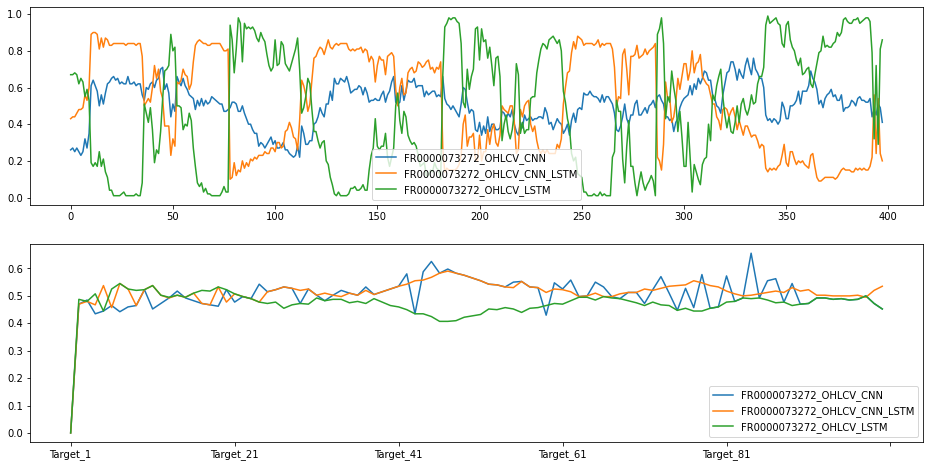

In [3]:
for file_true in ls_true:
    data_true = pd.read_parquet(os.path.join(forecast_path, file_true))
    fig, ax = plt.subplots(2,1, figsize=(16,8))
    
    res = pd.DataFrame()
    res2 = pd.DataFrame()
    
    for file_pred in ls_pred:
        data_pred = pd.read_parquet(os.path.join(forecast_path, file_pred))
        
        mse_per_row = data_true.apply(lambda row: mean_squared_error(row, data_pred.loc[row.name]), axis=1)
        mse_per_column = data_true.apply(lambda col: mean_squared_error(col, data_pred[col.name]), axis=0)
        
        res = pd.concat([res, pd.DataFrame(mse_per_row, columns=[file_pred.split('.')[0]])], axis=1)
        res2 = pd.concat([res2, pd.DataFrame(mse_per_column, columns=[file_pred.split('.')[0]])], axis=1)
        
        sign_match = np.sign(data_true) == np.sign(data_pred)

        # Accuracy globale (tous éléments)
        accuracy_row = sign_match.mean(axis=1)
        accuracy_column = sign_match.mean(axis=0)
        #display(accuracy_row, accuracy_column)
        accuracy_row.plot(ax=ax[0], legend=True, label=file_pred.split('.')[0])
        accuracy_column.plot(ax=ax[1], legend=True, label=file_pred.split('.')[0])
        plt.legend()

display(res)


,FR0000073272_OHLCV_CNN,FR0000073272_OHLCV_CNN_LSTM,FR0000073272_OHLCV_LSTM
count,398.000000,398.000000,398.000000
mean,0.000043,0.000048,0.000052
std,0.000049,0.000045,0.000067
min,0.000005,0.000008,0.000003
25%,0.000017,0.000021,0.000018
50%,0.000027,0.000033,0.000030
75%,0.000052,0.000056,0.000061
max,0.000426,0.000349,0.000546
skew,4.272664,2.913274,4.076933
kurtosis,25.309746,12.687965,21.805321


,FR0000073272_OHLCV_CNN,FR0000073272_OHLCV_CNN_LSTM,FR0000073272_OHLCV_LSTM
count,1.000000e+02,1.000000e+02,1.000000e+02
mean,4.332493e-05,4.783497e-05,5.246789e-05
std,1.172844e-05,1.523911e-05,1.621716e-05
min,6.255680e-07,6.248934e-12,2.136054e-08
25%,3.903834e-05,4.099866e-05,4.794771e-05
50%,4.680635e-05,4.773070e-05,5.240063e-05
75%,5.092925e-05,5.871384e-05,6.513510e-05
max,5.749831e-05,7.524640e-05,7.441458e-05
skew,-1.752404e+00,-9.343409e-01,-1.240388e+00
kurtosis,3.368941e+00,1.214150e+00,1.835236e+00


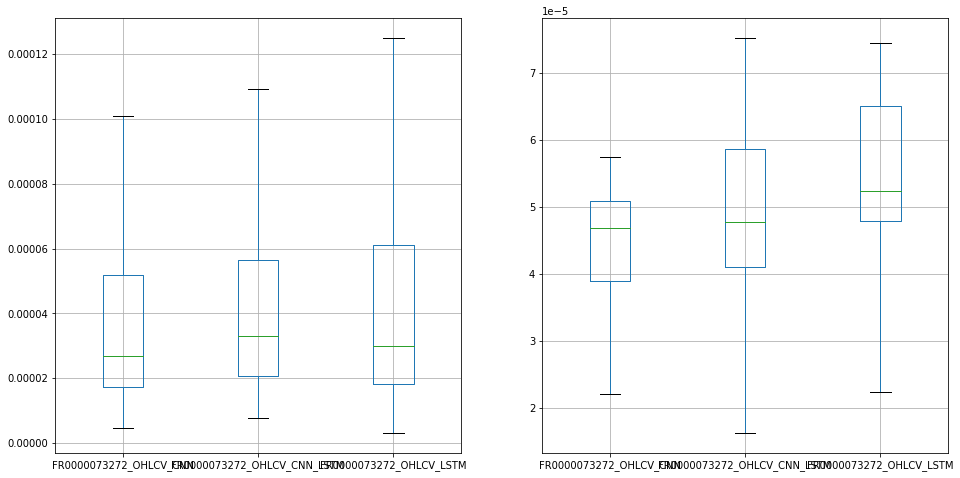

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))

res.boxplot(figsize=(16,8), showfliers=False, ax=ax[0])
desc = res.describe()

# Ajouter skewness et kurtosis
desc.loc['skew'] = res.skew()
desc.loc['kurtosis'] = res.kurt() 
display(desc)

res2.boxplot(figsize=(16,8), showfliers=False, ax=ax[1])
desc2 = res2.describe()

# Ajouter skewness et kurtosis
desc2.loc['skew'] = res2.skew()
desc2.loc['kurtosis'] = res2.kurt() 
display(desc2)

In [25]:
def temporal(row, data):
    try:
        data = data.loc[row.name:row.name + len(data.columns)].reset_index(drop=True)
        data = data.drop(['Target_1'], axis=1)
        data.index = data.index - 1
        ref = data.iloc[[0]].dropna(axis=1)
        data = data.apply(lambda x: x.shift(x.name), axis=1).reset_index(drop=True)
        mse = data.apply(lambda x: mean_squared_error(x.dropna(), ref[x.name].tolist()*len(x.dropna())), axis=0)

        return mse
    except: None

In [28]:
for file_true in ls_true:
    data_true = pd.read_parquet(os.path.join(forecast_path, file_true))
    
    res = pd.DataFrame()
    res2 = pd.DataFrame()
    
    for file_pred in ls_pred[:1]:
        data_pred = pd.read_parquet(os.path.join(forecast_path, file_pred))
        
        mse = data_pred.apply(lambda x: temporal(x, data_pred), axis=1).mean(axis=0)

display(mse)

Target_2      1.554762e-08
Target_3      1.686229e-07
Target_4      3.067924e-07
Target_5      1.486548e-07
Target_6      2.083094e-07
                  ...     
Target_96     7.237123e-06
Target_97     3.933510e-06
Target_98     1.576292e-06
Target_99     3.917741e-06
Target_100    2.415899e-06
Length: 99, dtype: float64

In [36]:
res_mse = mse.dropna(axis=0).describe()
display(res_mse)

,Target_2,Target_3,Target_4,Target_5,Target_6,Target_7,Target_8,Target_9,Target_10,Target_11,...,Target_91,Target_92,Target_93,Target_94,Target_95,Target_96,Target_97,Target_98,Target_99,Target_100
count,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,...,3.970000e+02,397.000000,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02,3.970000e+02
mean,1.554762e-08,1.686229e-07,3.067924e-07,1.486548e-07,2.083094e-07,1.100216e-07,1.789135e-07,1.026831e-06,1.092959e-06,9.192052e-07,...,2.230237e-06,0.000009,3.826494e-06,9.873965e-06,5.411604e-06,7.237123e-06,3.933510e-06,1.576292e-06,3.917741e-06,2.415899e-06
std,9.897359e-09,4.614945e-08,7.034704e-08,2.636372e-08,5.713656e-08,3.639778e-08,2.091124e-08,1.311490e-07,1.472089e-07,1.752345e-07,...,7.393050e-07,0.000002,1.150332e-06,2.305717e-06,1.629644e-06,2.085554e-06,1.292181e-06,4.713661e-07,1.402533e-06,9.102049e-07
min,2.901743e-10,7.254899e-08,9.785037e-08,3.124585e-08,3.682290e-08,5.412736e-08,8.388768e-08,6.977804e-07,6.816870e-07,4.101907e-07,...,6.603068e-07,0.000001,9.339565e-07,5.304876e-07,5.926815e-09,1.892991e-07,3.123413e-07,7.459666e-07,3.933252e-07,2.163093e-08
25%,8.432039e-09,1.377342e-07,2.554713e-07,1.299251e-07,1.663426e-07,8.228889e-08,1.646756e-07,9.289203e-07,9.934313e-07,7.860404e-07,...,1.710684e-06,0.000007,3.096363e-06,8.756716e-06,4.542245e-06,6.739993e-06,3.325403e-06,1.219781e-06,3.000444e-06,1.780755e-06
50%,1.318473e-08,1.620523e-07,3.016109e-07,1.460390e-07,1.986933e-07,9.975484e-08,1.766271e-07,1.023346e-06,1.092866e-06,9.075719e-07,...,2.058772e-06,0.000009,3.749378e-06,9.957770e-06,5.360926e-06,7.438500e-06,3.993221e-06,1.447810e-06,3.878100e-06,2.288842e-06
75%,2.096438e-08,1.949069e-07,3.575864e-07,1.657603e-07,2.443081e-07,1.302963e-07,1.917967e-07,1.112262e-06,1.196352e-06,1.037454e-06,...,2.709490e-06,0.000010,4.634439e-06,1.135867e-05,6.557154e-06,8.558511e-06,4.919380e-06,1.890276e-06,4.841213e-06,3.076678e-06
max,5.618652e-08,5.191585e-07,5.157908e-07,2.188768e-07,3.762301e-07,2.377933e-07,2.525305e-07,1.372029e-06,1.475286e-06,1.363787e-06,...,3.910807e-06,0.000014,6.357572e-06,1.444137e-05,8.660428e-06,1.069979e-05,6.088654e-06,2.818627e-06,7.134948e-06,4.497838e-06


<Axes: >

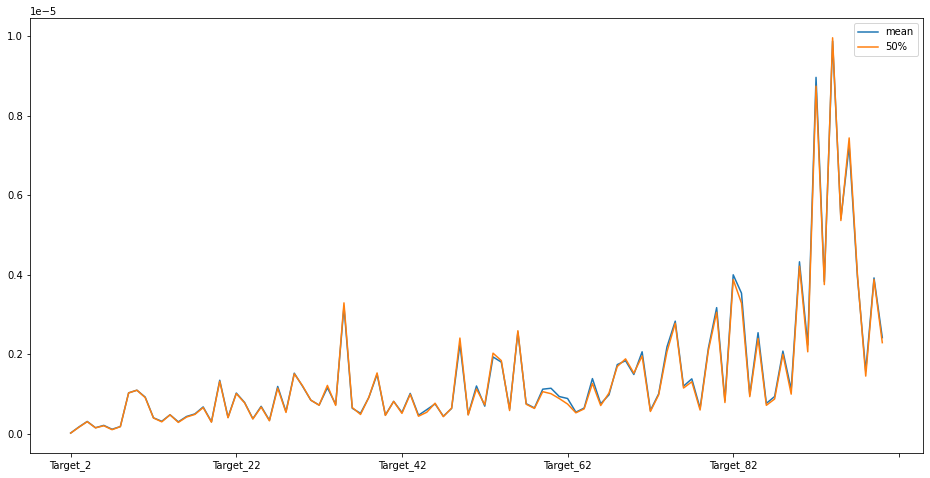

In [44]:
plot_mse = res_mse.loc[['mean','50%']]
display(plot_mse.T.plot(figsize=(16,8)))